In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm             import SVR
from sklearn.metrics         import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

df = pd.read_csv('updated_dataset.csv')

df

,nat_demand,holiday,school,avg_T2M,avg_QV2M,avg_TQL,avg_W2M,season,month,day_of_week,hour_of_day,is_weekend,year,nat_demand_1hr_lag,nat_demand_24hr_lag,nat_demand_1week_lag
0,906.9580,0,0,23.606704,0.016457,0.066152,13.350307,0,1,5,1,1,2015,949.5031,943.6081,970.3450
1,863.5135,0,0,23.544295,0.016462,0.063599,13.840689,0,1,5,2,1,2015,906.9580,917.0640,912.1755
2,848.4447,0,0,23.504724,0.016503,0.065865,14.086840,0,1,5,3,1,2015,863.5135,895.9092,900.2688
3,839.8821,0,0,23.527714,0.016571,0.062487,14.010866,0,1,5,4,1,2015,848.4447,885.2720,889.9538
4,847.1073,0,0,23.570540,0.016650,0.054685,13.581109,0,1,5,5,1,2015,839.8821,884.8111,893.6865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47875,1128.5592,0,1,25.569462,0.019477,0.109314,4.574912,2,6,4,20,0,2020,1127.2491,1279.2819,1207.3977
47876,1112.7488,0,1,25.448531,0.019449,0.121343,4.815926,2,6,4,21,0,2020,1128.5592,1260.8193,1175.9687
47877,1081.5680,0,1,25.340946,0.019431,0.118347,5.153183,2,6,4,22,0,2020,1112.7488,1226.9634,1123.2326
47878,1041.6240,0,1,25.242487,0.019408,0.108337,5.395190,2,6,4,23,0,2020,1081.5680,1184.3443,1080.3560


In [2]:
feature_cols = [
    'holiday','school','avg_T2M','avg_QV2M','avg_TQL','avg_W2M',
    'season','hour_of_day','is_weekend','year','month','day_of_week',
    'nat_demand_1hr_lag','nat_demand_24hr_lag','nat_demand_1week_lag'
]
X = df[feature_cols].values
y = df['nat_demand'].values

#  Time‐ordered split & scale
split = int(len(df) * 0.8)
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)


#  Baseline evaluation helper
def evaluate_model(model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0
    r2_tr = model.score(Xtr, ytr)
    r2_te = model.score(Xte, yte)
    ypred = model.predict(Xte)
    mae = mean_absolute_error(yte, ypred)
    mse = mean_squared_error(yte, ypred)
    mape= np.mean(np.abs((yte-ypred)/yte))
    return r2_tr, r2_te, train_time, mae, mse, mape

models = {
    'LinearRegression':  LinearRegression(),
    'DecisionTree':      DecisionTreeRegressor(),
    'RandomForest':      RandomForestRegressor(n_estimators=100,random_state=42),
    'GradientBoost':     GradientBoostingRegressor(n_estimators=100,random_state=42),
    'SVR':               SVR()
}

# Baseline
results_base = []
for name, mdl in models.items():
    stats = evaluate_model(mdl, X_tr_s, y_tr, X_te_s, y_te)
    results_base.append(dict(zip(['Model','Train R2','Test R2','Train Time','MAE','MSE','MAPE'],
        [name,*stats]
    )))
df_base = pd.DataFrame(results_base).set_index('Model')
print("=== Baseline Results ===")
display(df_base)




=== Baseline Results ===


,Train R2,Test R2,Train Time,MAE,MSE,MAPE
Model,,,,,,
LinearRegression,0.943994,0.939196,0.027367,35.425400,2103.556566,0.029431
DecisionTree,1.000000,0.960156,0.350323,25.779965,1378.445719,0.021617
RandomForest,0.998347,0.979247,23.382261,19.022677,717.968554,0.015914
GradientBoost,0.984047,0.975065,7.652477,22.096243,862.643230,0.018435
SVR,0.943280,0.863885,25.177103,51.377979,4708.993673,0.041743


In [3]:
class TimeSplitCNN(nn.Module):
    def __init__(self, in_ch, seq_len):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)
        self.pool  = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)
        self.drop  = nn.Dropout(0.5)
        self.fc1   = nn.Linear(64 * (seq_len//2), 128)
        self.fc2   = nn.Linear(128, 1)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        feat = self.relu(self.fc1(x))
        feat = self.drop(feat)
        out  = self.fc2(feat)
        return out, feat

# prepare tensors
Xtr_c = torch.tensor(X_tr_s, dtype=torch.float32).unsqueeze(1)
Xte_c = torch.tensor(X_te_s, dtype=torch.float32).unsqueeze(1)
ytr_c = torch.tensor(y_tr,    dtype=torch.float32).unsqueeze(1)

ds      = TensorDataset(Xtr_c, ytr_c)
loader  = DataLoader(ds, batch_size=64, shuffle=True)
seq_len = Xtr_c.shape[2]

cnn     = TimeSplitCNN(in_ch=1, seq_len=seq_len)
loss_fn = nn.MSELoss()
opt     = torch.optim.Adam(cnn.parameters(), lr=1e-3)
sched   = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.2)

# train
epochs = 40
cnn.train()
for ep in range(epochs):
    tot_loss = 0
    for xb, yb in loader:
        opt.zero_grad()
        pred, _ = cnn(xb)
        l = loss_fn(pred, yb)
        l.backward(); opt.step()
        tot_loss += l.item()*xb.size(0)
    sched.step()
    print(f"Epoch {ep+1}/{epochs} – Loss: {tot_loss/len(ds):.4f}")

# Extract CNN features & build hybrid
cnn.eval()
with torch.no_grad():
    _, feat_tr = cnn(Xtr_c)
    _, feat_te = cnn(Xte_c)

feat_tr_np = feat_tr.numpy()
feat_te_np = feat_te.numpy()

X_tr_hyb = np.hstack([X_tr_s, feat_tr_np])
X_te_hyb = np.hstack([X_te_s, feat_te_np])

scaler_h  = StandardScaler()
X_tr_h    = scaler_h.fit_transform(X_tr_hyb)
X_te_h    = scaler_h.transform(X_te_hyb)

# evaluate CNN-only & Hybrid
results_cnn   = []
results_hybrid= []

for name, mdl in models.items():
    stats_cnn = evaluate_model(mdl, feat_tr_np, y_tr, feat_te_np, y_te)
    stats_hyb = evaluate_model(mdl, X_tr_h,    y_tr, X_te_h,    y_te)
    results_cnn.append(dict(zip(['Model','Train R2','Test R2','Train Time','MAE','MSE','MAPE'],
        [name,*stats_cnn]
    )))
    results_hybrid.append(dict(zip(['Model','Train R2','Test R2','Train Time','MAE','MSE','MAPE'],
        [name,*stats_hyb]
    )))

df_cnn_only = pd.DataFrame(results_cnn).set_index('Model')
df_hybrid   = pd.DataFrame(results_hybrid).set_index('Model')

print("=== CNN-Only Results ===")
display(df_cnn_only)
print("=== Hybrid Results ===")
display(df_hybrid)



Epoch 1/40 – Loss: 248609.7336
Epoch 2/40 – Loss: 24549.2557
Epoch 3/40 – Loss: 23962.8875
Epoch 4/40 – Loss: 23651.0085
Epoch 5/40 – Loss: 23774.8940
Epoch 6/40 – Loss: 23501.8114
Epoch 7/40 – Loss: 23405.0692
Epoch 8/40 – Loss: 23616.8812
Epoch 9/40 – Loss: 23398.0937
Epoch 10/40 – Loss: 22718.8856
Epoch 11/40 – Loss: 22878.5186
Epoch 12/40 – Loss: 22985.8773
Epoch 13/40 – Loss: 22865.1436
Epoch 14/40 – Loss: 22805.7144
Epoch 15/40 – Loss: 22990.6758
Epoch 16/40 – Loss: 22498.2682
Epoch 17/40 – Loss: 22551.8082
Epoch 18/40 – Loss: 22961.2237
Epoch 19/40 – Loss: 22503.1358
Epoch 20/40 – Loss: 22784.6151
Epoch 21/40 – Loss: 22568.6364
Epoch 22/40 – Loss: 22881.5901
Epoch 23/40 – Loss: 22462.6309
Epoch 24/40 – Loss: 22500.7274
Epoch 25/40 – Loss: 22560.9223
Epoch 26/40 – Loss: 22761.9653
Epoch 27/40 – Loss: 22633.8247
Epoch 28/40 – Loss: 22719.1163
Epoch 29/40 – Loss: 22613.1397
Epoch 30/40 – Loss: 22339.7579
Epoch 31/40 – Loss: 22793.0592
Epoch 32/40 – Loss: 22557.5778
Epoch 33/40 – Lo

,Train R2,Test R2,Train Time,MAE,MSE,MAPE
Model,,,,,,
LinearRegression,0.971516,0.952509,0.046070,31.838769,1642.970585,0.026944
DecisionTree,1.000000,0.907204,3.117039,43.727942,3210.326444,0.036806
RandomForest,0.996502,0.946991,193.738377,33.513944,1833.896312,0.028393
GradientBoost,0.974265,0.947157,66.002330,33.597201,1828.137462,0.028451
SVR,0.968208,0.945878,187.082352,33.899319,1872.396897,0.028351


=== Hybrid Results ===


,Train R2,Test R2,Train Time,MAE,MSE,MAPE
Model,,,,,,
LinearRegression,0.972641,0.960370,0.084955,28.794095,1371.025763,0.024144
DecisionTree,1.000000,0.943087,3.084191,31.119464,1968.946767,0.026171
RandomForest,0.997931,0.966462,196.523392,25.357226,1160.267733,0.021500
GradientBoost,0.982212,0.961416,72.400033,28.251959,1334.852185,0.024022
SVR,0.968231,0.935387,90.542815,36.119038,2235.329291,0.030052


In [29]:
from sklearn.model_selection import TimeSeriesSplit

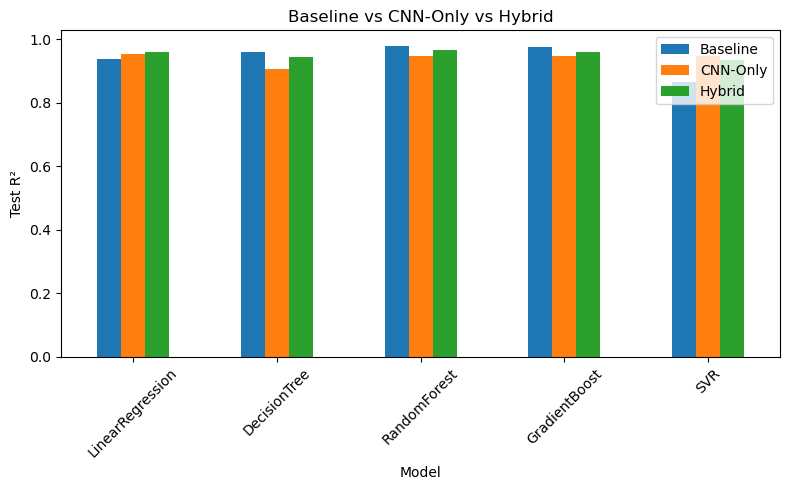

<Figure size 640x480 with 0 Axes>

In [22]:
# Compare all three
df_cmp = pd.DataFrame({
    'Baseline': df_base['Test R2'],
    'CNN-Only': df_cnn_only['Test R2'],
    'Hybrid':   df_hybrid['Test R2']
})
ax = df_cmp.plot.bar(figsize=(8,5))
ax.set_ylabel("Test R²")
ax.set_title("Baseline vs CNN-Only vs Hybrid")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('Baseline vs CNN-Only vs Hybrid.png')

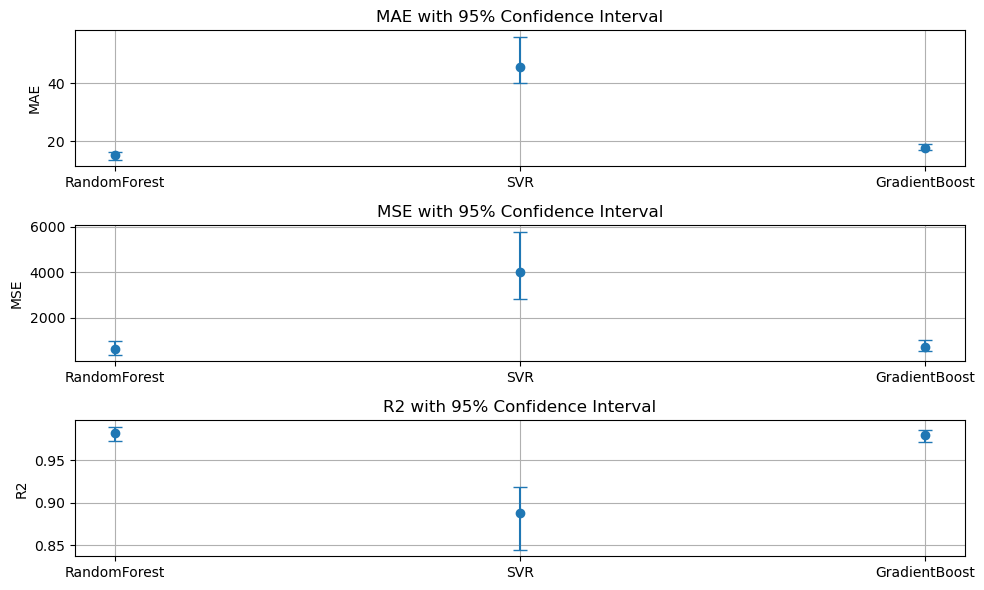

In [31]:
# TimeSeries Cross-Validation and Confidence Interval Summary


def evaluate_with_timeseries_cv(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    maes, mses, r2s = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        maes.append(mean_absolute_error(y_test, preds))
        mses.append(mean_squared_error(y_test, preds))
        r2s.append(model.score(X_test, y_test))

    def conf_interval(metric_list):
        mean = np.mean(metric_list)
        lower = np.percentile(metric_list, 2.5)
        upper = np.percentile(metric_list, 97.5)
        return mean, (lower, upper)

    results = {
        'MAE Mean (95% CI)': conf_interval(maes),
        'MSE Mean (95% CI)': conf_interval(mses),
        'R2 Mean (95% CI)':  conf_interval(r2s),
    }
    return results

# Apply to models
rf_results = evaluate_with_timeseries_cv(RandomForestRegressor(n_estimators=100, random_state=42), X_tr_s, y_tr)
svr_results = evaluate_with_timeseries_cv(SVR(), X_tr_s, y_tr)
gb_results = evaluate_with_timeseries_cv(GradientBoostingRegressor(n_estimators=100, random_state=42), X_tr_s, y_tr)

# Summary dictionary
results = {
    'RandomForest': {
        'MAE': rf_results['MAE Mean (95% CI)'],
        'MSE': rf_results['MSE Mean (95% CI)'],
        'R2':  rf_results['R2 Mean (95% CI)']
    },
    'SVR': {
        'MAE': svr_results['MAE Mean (95% CI)'],
        'MSE': svr_results['MSE Mean (95% CI)'],
        'R2':  svr_results['R2 Mean (95% CI)']
    },
    'GradientBoost': {
        'MAE': gb_results['MAE Mean (95% CI)'],
        'MSE': gb_results['MSE Mean (95% CI)'],
        'R2':  gb_results['R2 Mean (95% CI)']
    }
}

# Plotting CI summary
rows = []
for model, metrics in results.items():
    for metric, (mean, (low, high)) in metrics.items():
        rows.append({
            'Model': model,
            'Metric': metric,
            'Mean': mean,
            'CI Lower': low,
            'CI Upper': high
        })

df_ci = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
for i, metric in enumerate(['MAE', 'MSE', 'R2']):
    plt.subplot(3, 1, i + 1)
    metric_data = df_ci[df_ci['Metric'] == metric]
    plt.errorbar(metric_data['Model'], metric_data['Mean'],
                 yerr=[metric_data['Mean'] - metric_data['CI Lower'], 
                       metric_data['CI Upper'] - metric_data['Mean']],
                 fmt='o', capsize=5)
    plt.ylabel(metric)
    plt.title(f'{metric} with 95% Confidence Interval')
    plt.grid(True)

plt.tight_layout()